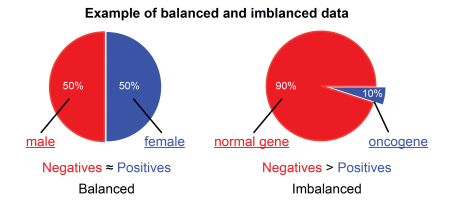

Problems -
1. Model become bias
2. Accuracy high on training but poor in unseen data

In [59]:
import pandas as pd

In [60]:
df = pd.read_csv("/content/Social_Network_Ads.csv")

In [61]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [62]:
df['Purchased'].value_counts()

,count
Purchased,
0,257
1,143


1. Undersampling

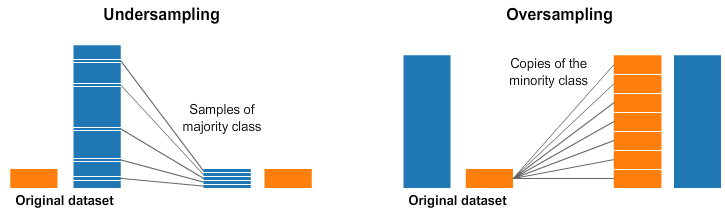

https://imbalanced-learn.org/stable/under_sampling.html

Dis Adv. - Information loss

In [63]:
X = df.drop('Purchased', axis=1)
y = df['Purchased']

In [64]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=0)
X_resampled, y_resampled = rus.fit_resample(X, y)

In [65]:
y_resampled.value_counts()

,count
Purchased,
0,143
1,143


2. Oversampling

Duplicate low class for balancing

Dis Adv - Duplication of data cause overfitting

In [66]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=0)
X_resampled_o, y_resampled_o = ros.fit_resample(X, y)

In [67]:
y_resampled_o.value_counts()

,count
Purchased,
0,257
1,257


3. SMOTE (Synthetic Minority Oversampling Technique)

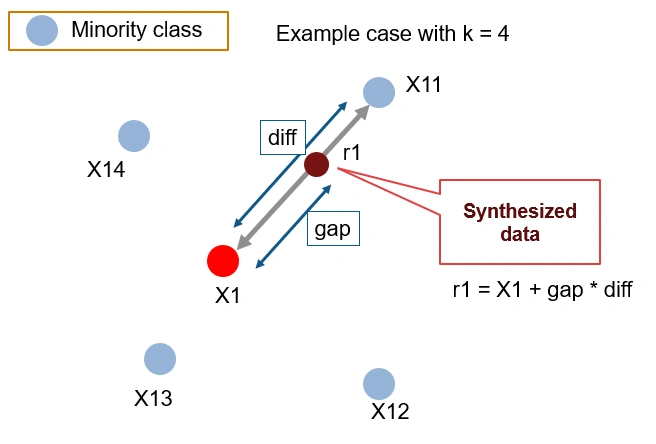

Not for Categorical data

In [68]:
from imblearn.over_sampling import SMOTE
X_resampled_s, y_resampled_s = SMOTE().fit_resample(X, y)

In [69]:
y_resampled_s.value_counts()

,count
Purchased,
0,257
1,257


4. Balanced Random Forest Classifier

https://imbalanced-learn.org/stable/references/generated/imblearn.ensemble.BalancedRandomForestClassifier.html

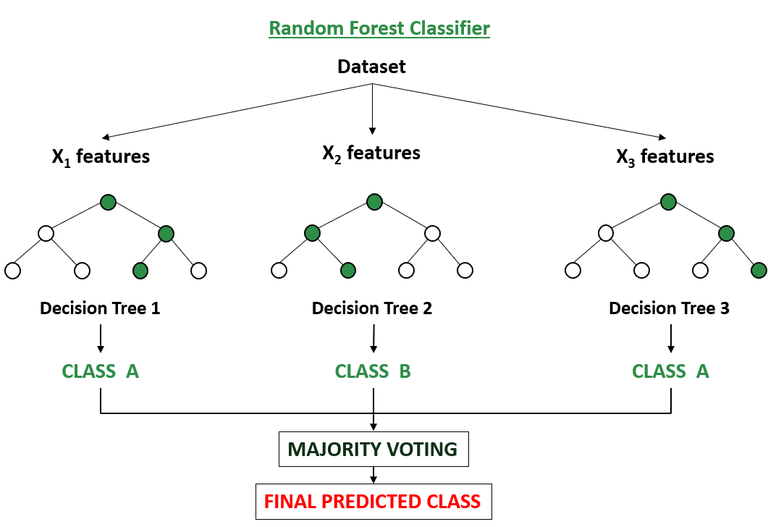

In [70]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2)

In [71]:
from imblearn.ensemble import BalancedRandomForestClassifier
clf = BalancedRandomForestClassifier(
    sampling_strategy="all", replacement=True, max_depth=2, random_state=0,
    bootstrap=False)
clf.fit(X_train, y_train)

BalancedRandomForestClassifier(max_depth=2, random_state=0)

In [72]:
clf.predict([[22,150000]])

array([1])

In [73]:
from sklearn.metrics import accuracy_score
y_pred = clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.9625

Class weight

In [74]:
 from sklearn.ensemble import RandomForestClassifier

In [75]:
clf = RandomForestClassifier(max_depth=2, random_state=0,class_weight = {0:1,1:2})   #give more weight to class 1